In [2]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("D:\ds9.reg", "r") as f:
    content = f.read()

print(content)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_24344\2110435709.py:1: SyntaxWarning: invalid escape sequence '\d'
  with open("D:\ds9.reg", "r") as f:


# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
icrs
circle(273.1722669,64.1051539,15.966")
circle(273.1195623,64.1244674,9.067")



In [4]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [4]:
df_total = pd.read_pickle('../../all_fluxes_north.pkl')

In [5]:
df_total.columns

Index(['id', 'tile_index', 'ra', 'dec', 'FWHM', 'point_source_probability_mer',
       'FLUX_NIR-H_0.5FWHM', 'FLUXERR_NIR-H_0.5FWHM', 'FLUX_CFIS-R_0.5FWHM',
       'FLUXERR_CFIS-R_0.5FWHM', 'FLUX_NIR-Y_0.5FWHM', 'FLUXERR_NIR-Y_0.5FWHM',
       'FLUX_CFIS-U_0.5FWHM', 'FLUXERR_CFIS-U_0.5FWHM', 'FLUX_NIR-J_0.5FWHM',
       'FLUXERR_NIR-J_0.5FWHM', 'FLUX_PANSTARRS-I_0.5FWHM',
       'FLUXERR_PANSTARRS-I_0.5FWHM', 'FLUX_VIS_0.5FWHM',
       'FLUXERR_VIS_0.5FWHM', 'FLUX_WISHES-Z_0.5FWHM',
       'FLUXERR_WISHES-Z_0.5FWHM', 'FLUX_WISHES-G_0.5FWHM',
       'FLUXERR_WISHES-G_0.5FWHM', 'FLUX_NIR-J_1FWHM', 'FLUXERR_NIR-J_1FWHM',
       'FLUX_CFIS-U_1FWHM', 'FLUXERR_CFIS-U_1FWHM', 'FLUX_NIR-H_1FWHM',
       'FLUXERR_NIR-H_1FWHM', 'FLUX_CFIS-R_1FWHM', 'FLUXERR_CFIS-R_1FWHM',
       'FLUX_NIR-Y_1FWHM', 'FLUXERR_NIR-Y_1FWHM', 'FLUX_WISHES-Z_1FWHM',
       'FLUXERR_WISHES-Z_1FWHM', 'FLUX_PANSTARRS-I_1FWHM',
       'FLUXERR_PANSTARRS-I_1FWHM', 'FLUX_WISHES-G_1FWHM',
       'FLUXERR_WISHES-G_1FWHM', 'FL

In [6]:
bands = ['CFIS-U', 'WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']
# bands = ['CFIS-U', 'WISHES-G','CFIS-R','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']
mask = pd.Series(True, index=df_total.index)

for FWHM in [0.5, 1, 2]:
    for b in bands:
        mask &= df_total[f'FLUX_{b}_{FWHM}FWHM'] / df_total[f'FLUXERR_{b}_{FWHM}FWHM'] > 2
df_sel = df_total[mask].copy()
print(len(df_sel), len(df_total))

134522 11378352


In [7]:
for FWHM in [0.5, 1, 2]:
    for b in bands:
        df_sel[f'MAG_{b}_{FWHM}FWHM'] = -2.5*np.log10(df_sel[f'FLUX_{b}_{FWHM}FWHM'])

In [8]:
for FWHM in [0.5, 1, 2]:
    for i in range(len(bands)-1):
        for j in range(i+1, len(bands)):
            df_sel[f'{bands[i]}-{bands[j]}_{FWHM}FWHM'] = df_sel[f'MAG_{bands[i]}_{FWHM}FWHM'] - df_sel[f'MAG_{bands[j]}_{FWHM}FWHM']
df_sel = df_sel.copy()

C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_2052\3418644154.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sel[f'{bands[i]}-{bands[j]}_{FWHM}FWHM'] = df_sel[f'MAG_{bands[i]}_{FWHM}FWHM'] - df_sel[f'MAG_{bands[j]}_{FWHM}FWHM']


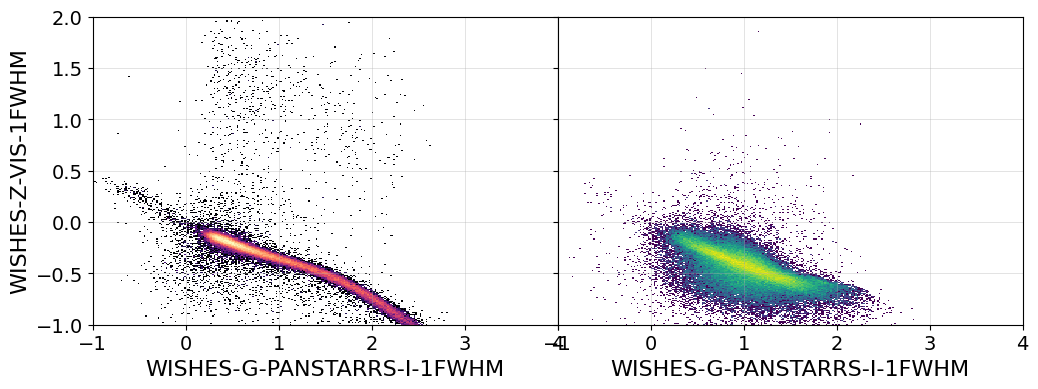

In [9]:
xmin, xmax = -1, 4
ymin, ymax = -1, 2
n_bins = 300
x_bins = np.linspace(xmin, xmax, n_bins + 1)
y_bins = np.linspace(ymin, ymax, n_bins + 1)
bins = (x_bins, y_bins)
x_color = 'WISHES-G-PANSTARRS-I_1FWHM'
y_color = 'WISHES-Z-VIS_1FWHM'
mask = df_sel['point_source_probability_mer'] <= .7
fig, axes = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(12, 4), gridspec_kw={'wspace': 0, 'hspace': 0})
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
mask = df_sel['point_source_probability_mer'] > .7
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
# plt.title(f'{np.sum(mask)} sources > .7 PSP {np.sum(~mask)} sources < .7 PSP')
# plt.grid()
# plt.xlabel(x_color.replace('_', '-'))
# plt.ylabel(y_color.replace('_', '-
# '))
for ax in axes:
    ax.grid(True)
    ax.set_xlabel(x_color.replace('_', '-'))
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
axes[0].set_ylabel(y_color.replace('_', '-'))
# plt.savefig('psp_hist.png')
plt.show()

In [10]:
features = []
for FWHM in [1]:
    for i in range(len(bands)-1):
        for j in range(i+1, len(bands)):
            features.append(f'{bands[i]}-{bands[j]}_{FWHM}FWHM')
X = df_sel[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
print(len(X), len(df_sel))
print(features)

134522 134522
['CFIS-U-WISHES-G_1FWHM', 'CFIS-U-CFIS-R_1FWHM', 'CFIS-U-PANSTARRS-I_1FWHM', 'CFIS-U-WISHES-Z_1FWHM', 'CFIS-U-VIS_1FWHM', 'CFIS-U-NIR-Y_1FWHM', 'CFIS-U-NIR-J_1FWHM', 'CFIS-U-NIR-H_1FWHM', 'WISHES-G-CFIS-R_1FWHM', 'WISHES-G-PANSTARRS-I_1FWHM', 'WISHES-G-WISHES-Z_1FWHM', 'WISHES-G-VIS_1FWHM', 'WISHES-G-NIR-Y_1FWHM', 'WISHES-G-NIR-J_1FWHM', 'WISHES-G-NIR-H_1FWHM', 'CFIS-R-PANSTARRS-I_1FWHM', 'CFIS-R-WISHES-Z_1FWHM', 'CFIS-R-VIS_1FWHM', 'CFIS-R-NIR-Y_1FWHM', 'CFIS-R-NIR-J_1FWHM', 'CFIS-R-NIR-H_1FWHM', 'PANSTARRS-I-WISHES-Z_1FWHM', 'PANSTARRS-I-VIS_1FWHM', 'PANSTARRS-I-NIR-Y_1FWHM', 'PANSTARRS-I-NIR-J_1FWHM', 'PANSTARRS-I-NIR-H_1FWHM', 'WISHES-Z-VIS_1FWHM', 'WISHES-Z-NIR-Y_1FWHM', 'WISHES-Z-NIR-J_1FWHM', 'WISHES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']


In [11]:
Xn = StandardScaler().fit_transform(X)

In [12]:
embedding_2d = umap.UMAP(
    n_neighbors=50,
    min_dist=0
).fit_transform(Xn)

In [13]:
clusterer = HDBSCAN(
    min_cluster_size=1000,
    min_samples=50
)

labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([0, 1]), array([45884, 88638]))


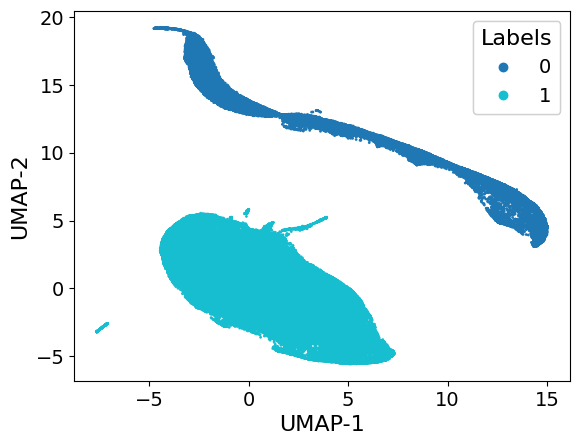

In [14]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.title("EDF-N")
plt.savefig('../../results/figures/analysis/UMAP_splitting_north.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

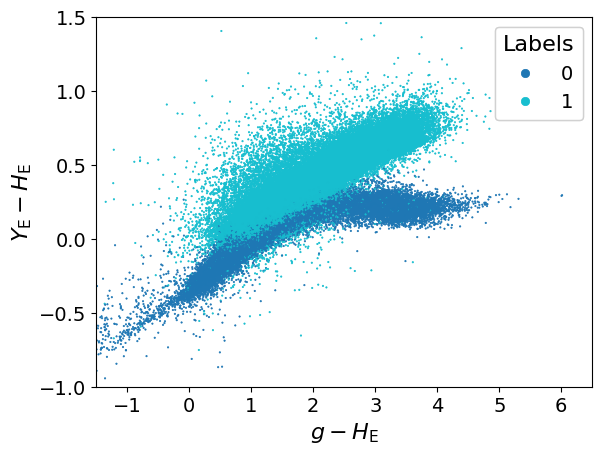

In [15]:
mask = labels != -1

scatter = plt.scatter(
    df_sel['WISHES-G-NIR-H_1FWHM'][mask],
    df_sel['NIR-Y-NIR-H_1FWHM'][mask],
    c=labels[mask],
    s=1,
    cmap='tab10',
    marker='o',
    linewidths=0.5,
    label='DBSCAN',
    rasterized=True
)

legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)

plt.xlabel(r'$g-H_\mathrm{E}$')
plt.ylabel(r'$Y_\mathrm{E}-H_\mathrm{E}$')
plt.xlim(-1.5, 6.5)
plt.ylim(-1, 1.5)
plt.title("EDF-N")
plt.savefig('../../results/figures/analysis/color_color_splitting_north.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

In [16]:
galaxy = df_sel[labels==1]
star = df_sel[labels==0]

In [5]:
pd.to_pickle(galaxy, 'galaxy_north.pkl')
pd.to_pickle(star, 'star_north.pkl')

NameError: name 'galaxy' is not defined

In [6]:
galaxy =  pd.read_pickle('galaxy_north.pkl')
star =  pd.read_pickle('star_north.pkl')
bands = ['CFIS-U', 'WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']

In [47]:
selection = galaxy

In [48]:
for band in bands:
    selection[f'DELTA_FLUX_{band}_0'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_1FWHM'])/selection[f'FLUX_{band}_1FWHM']
    selection[f'DELTA_FLUX_{band}_1'] = (selection[f'FLUX_{band}_1FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']
    selection[f'DELTA_FLUX_{band}_2'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']

In [49]:
features = ['CFIS-U-WISHES-G_1FWHM', 'CFIS-U-CFIS-R_1FWHM', 'CFIS-U-PANSTARRS-I_1FWHM', 'CFIS-U-WISHES-Z_1FWHM', 'CFIS-U-VIS_1FWHM', 'CFIS-U-NIR-Y_1FWHM', 'CFIS-U-NIR-J_1FWHM', 'CFIS-U-NIR-H_1FWHM', 'WISHES-G-CFIS-R_1FWHM', 'WISHES-G-PANSTARRS-I_1FWHM', 'WISHES-G-WISHES-Z_1FWHM', 'WISHES-G-VIS_1FWHM', 'WISHES-G-NIR-Y_1FWHM', 'WISHES-G-NIR-J_1FWHM', 'WISHES-G-NIR-H_1FWHM', 'CFIS-R-PANSTARRS-I_1FWHM', 'CFIS-R-WISHES-Z_1FWHM', 'CFIS-R-VIS_1FWHM', 'CFIS-R-NIR-Y_1FWHM', 'CFIS-R-NIR-J_1FWHM', 'CFIS-R-NIR-H_1FWHM', 'PANSTARRS-I-WISHES-Z_1FWHM', 'PANSTARRS-I-VIS_1FWHM', 'PANSTARRS-I-NIR-Y_1FWHM', 'PANSTARRS-I-NIR-J_1FWHM', 'PANSTARRS-I-NIR-H_1FWHM', 'WISHES-Z-VIS_1FWHM', 'WISHES-Z-NIR-Y_1FWHM', 'WISHES-Z-NIR-J_1FWHM', 'WISHES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']
for band in bands:
    for i in range(3):
        features.append(f'DELTA_FLUX_{band}_{i}')

X = selection[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
Xn = StandardScaler().fit_transform(X)

In [50]:
embedding_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.0,
    random_state=21
).fit_transform(Xn)

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [51]:
clusterer = HDBSCAN(min_cluster_size=50,
                    min_samples=10, n_jobs=5)
clusterer = DBSCAN(eps=0.2, min_samples=20)

# labels = clusterer.fit_predict(embedding_2d)
# labels[labels == 1] = 1000
labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5]), array([   42, 85082,  1946,   799,   413,   123,   233]))


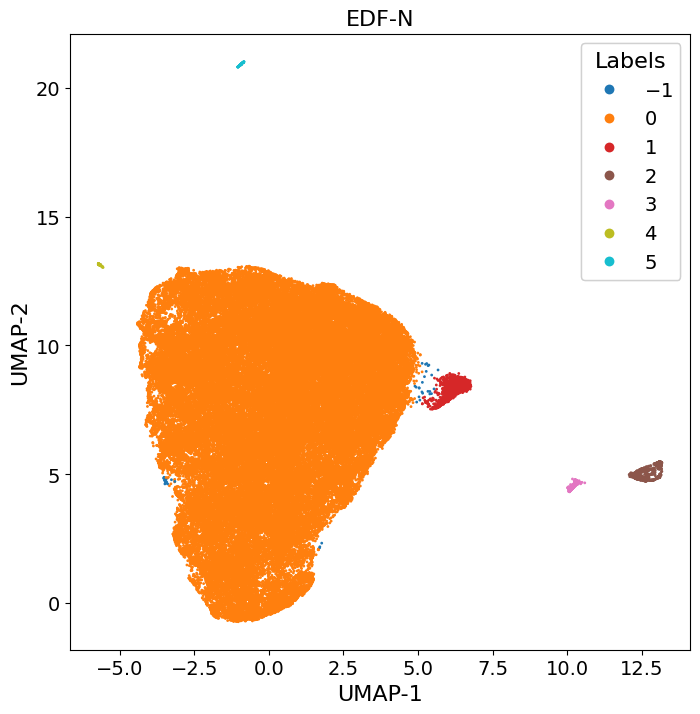

In [52]:
plt.figure(figsize=(8,8))
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.title("EDF-N")
plt.savefig('../../results/figures/analysis/UMAP_galaxy_north.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

In [45]:
def make_table(selection, label, type, field):
    cat = pd.read_pickle('all_class_data.pkl')
    matches = cat[cat['OBJECT_ID'].isin(selection['id'])]
    height, _ = np.histogram(matches['PHZ_CLASSIFICATION'], bins=np.arange(0, 10)-0.5, density=True)
    with open(f"../../results/tables/{type}/{field}/{label}.txt", "w") as f:
          f.write(" & ".join(f"{x * 100:.2f}\\%" for x in height))

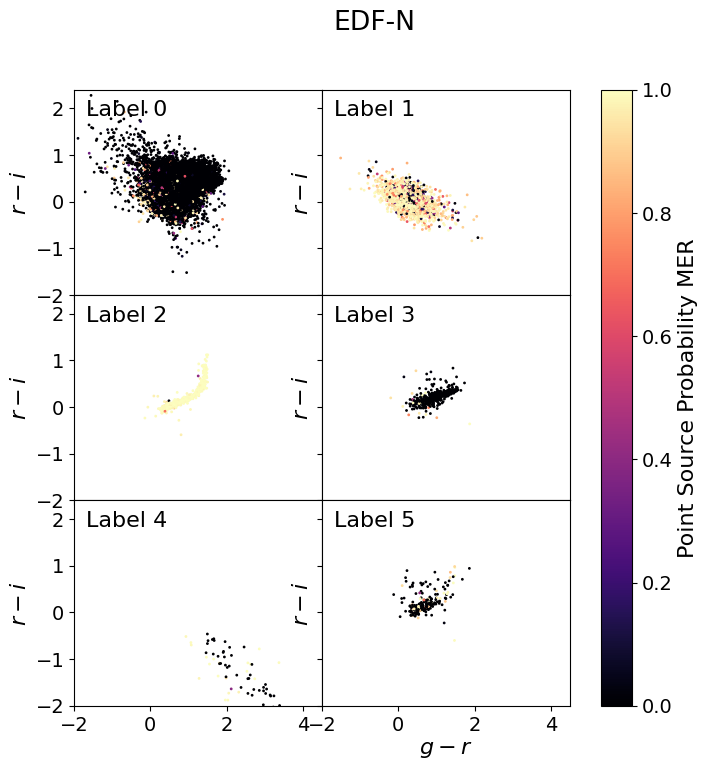

In [53]:
mask = labels == 0
x_color = 'WISHES-G-CFIS-R_1FWHM'
y_color = 'CFIS-R-PANSTARRS-I_1FWHM'

fig, axes = plt.subplots(3,2, sharey=True, sharex=True, figsize=(8,8), gridspec_kw={'wspace': 0, 'hspace': 0})
axes = axes.flatten()
x_min, x_max = -2, 4.5
y_min, y_max = -2, 2.4
for i, label in enumerate(range(6)):
    mask = labels == label
    sc1  = axes[i].scatter(
        galaxy[x_color][mask],
        galaxy[y_color][mask],
        c=galaxy['point_source_probability_mer'][mask],
        vmin=0, vmax=1,
        s=1,
        marker='o',
        label='DBSCAN',
        rasterized=True
    )
    axes[i].text(
    0.05, 0.95, f"Label {label}",
    transform=axes[i].transAxes,
    va="top"
)
    make_table(galaxy[mask], label, 'galaxy', 'north')
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
axes[-1].set_xlabel(r"$g-r$")
fig.colorbar(sc1, ax=axes, label="Point Source Probability MER")
fig.suptitle("EDF-N")
plt.savefig('../../results/figures/analysis/color_color_galaxy_north.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

In [53]:
star_like = selection[labels==2]
galaxy_like = selection[labels == 3]
galaxy = selection[labels == 0]
quasar = selection[labels == 1]

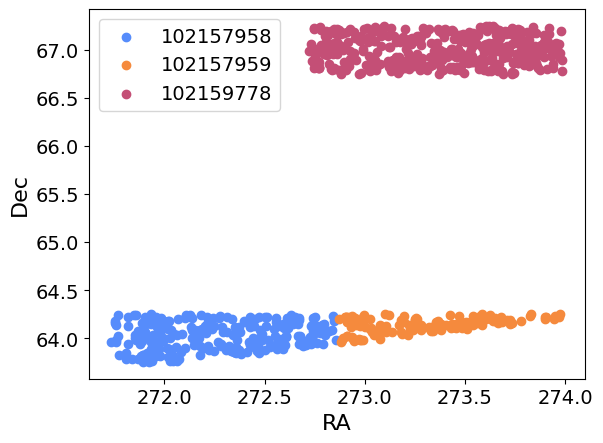

In [54]:
# plt.figure(figsize=(15,10))
plt.scatter(star_like['ra'][star_like['tile_index'] == 102157958], star_like['dec'][star_like['tile_index'] == 102157958], label='102157958')
# plt.xlim(np.nanmin(galaxy['ra'][galaxy['tile_index'] == 102157958]), np.nanmax(galaxy['ra'][galaxy['tile_index'] == 102157958]))
# plt.ylim(np.nanmin(galaxy['dec'][galaxy['tile_index'] == 102157958]), np.nanmax(galaxy['dec'][galaxy['tile_index'] == 102157958]))
plt.scatter(star_like['ra'][star_like['tile_index'] == 102157959], star_like['dec'][star_like['tile_index'] == 102157959], label='102157959')
plt.scatter(star_like['ra'][star_like['tile_index'] == 102159778], star_like['dec'][star_like['tile_index'] == 102159778], label='102159778')
plt.legend()
plt.xlabel("RA")
plt.ylabel("Dec")
plt.show()

In [67]:
sel = galaxy.sort_values(by='FWHM').iloc[:1000]
sel = selection[labels==6].iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), *tileindex, len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == 102157959.0]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
# ds9_regions(coords[coords[:, 0] == 102157958], 5)

6 102157953.0 102158585.0 102158896.0 102159489.0 102159774.0 102160608.0 232
102158896.0 61
np.array([
])


In [68]:
group = star_like
other = galaxy
group_mean = group.mean(axis=0)
rest_mean = other.mean(axis=0)

global_std = selection.std(axis=0)

delta = (group_mean - rest_mean) / global_std

importance = pd.Series(
    delta,
    index=features
).sort_values(key=np.abs, ascending=False)

print(importance)

WISHES-Z-VIS_1FWHM            6.600959
PANSTARRS-I-WISHES-Z_1FWHM   -6.589027
WISHES-Z-NIR-Y_1FWHM          6.531590
WISHES-Z-NIR-J_1FWHM          5.107914
CFIS-R-WISHES-Z_1FWHM        -5.005406
                                ...   
DELTA_FLUX_NIR-J_1                 NaN
DELTA_FLUX_NIR-J_2                 NaN
DELTA_FLUX_NIR-H_0                 NaN
DELTA_FLUX_NIR-H_1                 NaN
DELTA_FLUX_NIR-H_2                 NaN
Length: 63, dtype: float64


In [69]:
sel = galaxy.sort_values(by='FWHM').iloc[:1000]
sel = galaxy.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

117 88637
102158889.0 2082
np.array([
    (267.553995, 65.248997),
    (267.888494, 65.249078),
    (267.876929, 65.246238),
    (267.874697, 65.248974),
    (267.878571, 65.248621),
    (267.914117, 65.249849),
    (267.158951, 65.249997),
    (267.302735, 65.250659),
    (267.807634, 65.250063),
    (267.300884, 65.251307),
    (266.807048, 65.250912),
    (266.816152, 65.251741),
    (267.592448, 65.253105),
    (267.562505, 65.253202),
    (267.289328, 65.253500),
    (266.835122, 65.252869),
    (267.536097, 65.253997),
    (267.758218, 65.253873),
    (267.151950, 65.254348),
    (267.696962, 65.254429),
    (266.907184, 65.254232),
    (267.936086, 65.254087),
    (266.831439, 65.254326),
    (267.809184, 65.254388),
    (266.886362, 65.254837),
    (266.999325, 65.255220),
    (266.865194, 65.254910),
    (267.692782, 65.255731),
    (266.855711, 65.255343),
    (267.788935, 65.255898),
    (267.755875, 65.256109),
    (267.116198, 65.256599),
    (267.792872, 65.256577),
    (

In [70]:
sel = galaxy.sort_values(by='FWHM').iloc[:1000]
sel = quasar.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == 102157958]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

104 1954
102159191.0 36
np.array([
    (272.509703, 63.886697),
    (272.376744, 63.903600),
    (272.047651, 64.203533),
])


In [54]:
selection = star

In [55]:
for band in bands:
    selection[f'DELTA_FLUX_{band}_0'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_1FWHM'])/selection[f'FLUX_{band}_1FWHM']
    selection[f'DELTA_FLUX_{band}_1'] = (selection[f'FLUX_{band}_1FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']
    selection[f'DELTA_FLUX_{band}_2'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']

In [56]:
features = ['CFIS-U-WISHES-G_1FWHM', 'CFIS-U-CFIS-R_1FWHM', 'CFIS-U-PANSTARRS-I_1FWHM', 'CFIS-U-WISHES-Z_1FWHM', 'CFIS-U-VIS_1FWHM', 'CFIS-U-NIR-Y_1FWHM', 'CFIS-U-NIR-J_1FWHM', 'CFIS-U-NIR-H_1FWHM', 'WISHES-G-CFIS-R_1FWHM', 'WISHES-G-PANSTARRS-I_1FWHM', 'WISHES-G-WISHES-Z_1FWHM', 'WISHES-G-VIS_1FWHM', 'WISHES-G-NIR-Y_1FWHM', 'WISHES-G-NIR-J_1FWHM', 'WISHES-G-NIR-H_1FWHM', 'CFIS-R-PANSTARRS-I_1FWHM', 'CFIS-R-WISHES-Z_1FWHM', 'CFIS-R-VIS_1FWHM', 'CFIS-R-NIR-Y_1FWHM', 'CFIS-R-NIR-J_1FWHM', 'CFIS-R-NIR-H_1FWHM', 'PANSTARRS-I-WISHES-Z_1FWHM', 'PANSTARRS-I-VIS_1FWHM', 'PANSTARRS-I-NIR-Y_1FWHM', 'PANSTARRS-I-NIR-J_1FWHM', 'PANSTARRS-I-NIR-H_1FWHM', 'WISHES-Z-VIS_1FWHM', 'WISHES-Z-NIR-Y_1FWHM', 'WISHES-Z-NIR-J_1FWHM', 'WISHES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']
for band in bands:
    for i in range(3):
        features.append(f'DELTA_FLUX_{band}_{i}')

X = selection[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
Xn = StandardScaler().fit_transform(X)

In [57]:
embedding_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.0,
    random_state=21,
).fit_transform(Xn)

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [58]:
clusterer = HDBSCAN(min_cluster_size=500,
                    min_samples=10, n_jobs=5)
clusterer = DBSCAN(eps=0.3)

# labels = clusterer.fit_predict(embedding_2d)
# labels[labels == 1] = 1000
labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

(array([-1,  0,  1,  2,  3]), array([    3, 40809,  4223,   811,    38]))


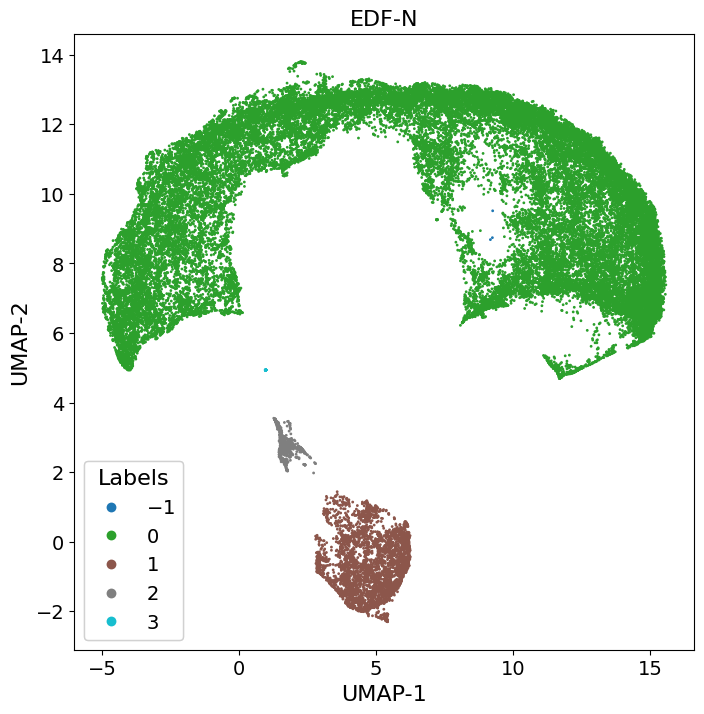

In [59]:
plt.figure(figsize=(8,8))
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.title('EDF-N')
plt.savefig('../../results/figures/analysis/UMAP_star_north.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

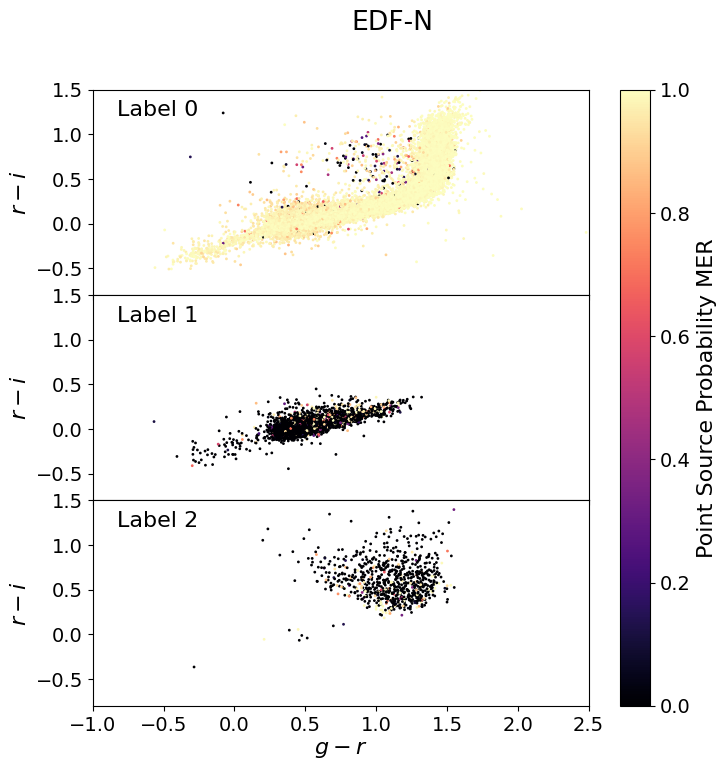

In [60]:
mask = labels == 0
x_color = 'WISHES-G-CFIS-R_1FWHM'
y_color = 'CFIS-R-PANSTARRS-I_1FWHM'

fig, axes = plt.subplots(3,1, sharey=True, sharex=True, figsize=(8,8), gridspec_kw={'wspace': 0, 'hspace': 0})

x_min, x_max = -1, 2.5
y_min, y_max = -0.8, 1.5
for i in range(3):
    mask = labels == i
    sc1  = axes[i].scatter(
        selection[x_color][mask],
        selection[y_color][mask],
        c=selection['point_source_probability_mer'][mask],
        vmin=0, vmax=1,
        s=1,
        marker='o',
        label='DBSCAN',
        rasterized=True
    )
    axes[i].text(
    0.05, 0.95, f"Label {i}",
    transform=axes[i].transAxes,
    va="top"
)
    make_table(selection[mask], i, 'star', 'north')
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
axes[-1].set_xlabel(r"$g-r$")
fig.colorbar(sc1, ax=axes, label="Point Source Probability MER")
fig.suptitle("EDF-N")
plt.savefig('../../results/figures/analysis/color_color_star_north.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

In [ ]:
extended_star = star[labels==1]
not_extended_star = star[labels==0]

In [ ]:
sel = extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

In [ ]:
sel = not_extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

In [ ]:
pd.to_pickle(quasar, 'classes/quasar_north.pkl')
pd.to_pickle(galaxy, 'classes/non_quasar_north.pkl')
pd.to_pickle(extended_star, 'classes/extended_star_north.pkl')
pd.to_pickle(not_extended_star, 'classes/not_extended_star_north.pkl')
pd.to_pickle(star_like, 'classes/star_like_north.pkl')

### JUST ANALYZING THE CLASSES

In [ ]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob
from astropy.io import fits
from astropy.table import Table

In [ ]:
def ds9_regions(coords, opening=5):
    with open("D:\ds9_new.reg", "w") as f:
        f.write("# Region file format: DS9 version 4.1\n")
        f.write("global color=green\n")
        f.write("fk5\n")
        for i, (_, x, y) in enumerate(coords):
            f.write(f'circle({x},{y},{opening}")\n')
            f.write(f'circle({x},{y},{opening/100}")\n')

In [ ]:
quasar = pd.read_pickle('classes/quasar_north.pkl')
galaxy = pd.read_pickle('classes/non_quasar_north.pkl')
extended_star = pd.read_pickle('classes/extended_star_north.pkl')
star = pd.read_pickle('classes/not_extended_star_north.pkl')
star_like = pd.read_pickle('classes/star_like_north.pkl')
cat = pd.read_pickle('all_class_data.pkl')

In [ ]:
sel = extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(102157958 in tileindex)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == 102157958]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
print(coords[coords[:, 0] == '102157958'])
ds9_regions(coords[coords[:, 0] == '102157958'])

In [ ]:
df_total = pd.read_pickle('../../all_fluxes_north.pkl')

In [ ]:
mask = (df_total['tile_index'] == 102157958) | (df_total['tile_index'] == 102157959) | (df_total['tile_index'] == 102159778)
weird_tiles = df_total[mask]
weird_tiles = weird_tiles[~np.isnan(weird_tiles)]
normal_tiles = df_total[~mask]
normal_tiles = normal_tiles[~np.isnan(normal_tiles)]

In [ ]:
fig, axes = plt.subplots(3, 9, figsize=(15, 6))
bins = np.logspace(1, 4, 500)
bands = {'CFIS-U':0, 'WISHES-G':1,'CFIS-R':2,'PANSTARRS-I':3,'WISHES-Z':4,'VIS':5,'NIR-Y':6,'NIR-J':7,'NIR-H':8}
for column in normal_tiles.columns:
    if 'ERR' not in column and 'FLUX' in column:
        i = bands[column.split('_')[1]]
        j = int(float(column.split('_')[-1].split('F')[0]))
        ax = axes[j, i]
        # print(int(float(column.split('_')[-1].split('F')[0])))
        # print(column, (np.nanmean(normal_tiles[column]) - np.nanmean(weird_tiles[column]))/np.nanmean(normal_tiles[column]))
        # # if 'WISHES-Z' in column:
        if i == 0:
            ax.set_ylabel(column.split('_')[-1])
        if j == 0:
            ax.set_title(column.split('_')[1])

        counts, edges = np.histogram(normal_tiles[column][normal_tiles[column]>0], bins=bins)
        bin_widths = np.diff(edges)

        density = counts / (counts.sum() * bin_widths)

        ax.plot(edges[:-1], density)
        counts, edges = np.histogram(weird_tiles[column][weird_tiles[column]>0], bins=bins)
        bin_widths = np.diff(edges)

        density = counts / (counts.sum() * bin_widths)

        ax.plot(edges[:-1], density)
        ax.set_xscale('log')
        ax.set_xticks([])
        ax.set_yticks([])
fig.supxlabel("Flux [a.u.]", fontsize=20)
fig.supylabel("Density", fontsize=16)
fig.tight_layout()
fig.supylabel("PDF")
        # plt.show()

In [ ]:
with open("class_files.csv", "r", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)
    for row in reader:
        file = glob.glob(f"C:/catalog_files/{row[0]}")[0]
        with fits.open(file, memmap=True) as hdul:
            cat = Table(hdul[1].data)
        cat = cat.to_pandas()
        cat = cat[['OBJECT_ID', 'PHZ_STAR_PROB', 'PHZ_GAL_PROB',
       'PHZ_QSO_PROB', 'PHZ_GLOB_CL_PROB', 'PHZ_CLASSIFICATION']]
        dfs.append(cat)

combined_df = pd.concat(dfs, ignore_index=True)

In [ ]:
file = glob.glob("C:/catalog_files/EUC_PHZ_CLASSCAT__20241120T094730.789055Z_00.00.fits")[0]
with fits.open(file, memmap=True) as hdul:
    print(hdul[1].header)

In [ ]:
cat = cat.to_pandas()

In [ ]:
cat.columns

In [ ]:
quasar

In [ ]:
matches = cat[cat['OBJECT_ID'].isin(star['id'])]
height, _ = np.histogram(matches['PHZ_CLASSIFICATION'], bins=np.arange(0, 10)-0.5, density=True)
labels = ['Not Accepted', 'Star', 'Galaxy', 'Star + Galaxy', 'QSO', 'QSO + Star', 'QSO + Galaxy', 'QSO + Star + Galaxy']
table = ''
for label, h in zip(labels, height):
    table += f"{label:<20} | {h * 100:.2f}%\n"

print(table)